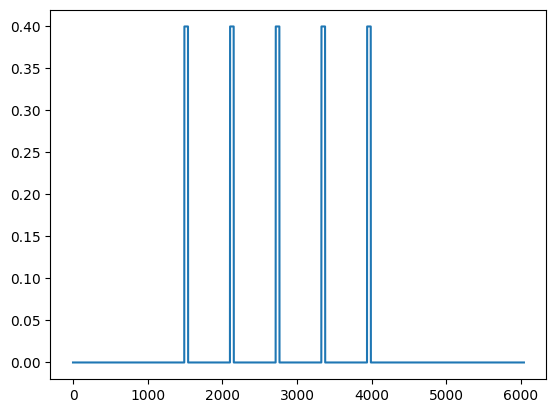

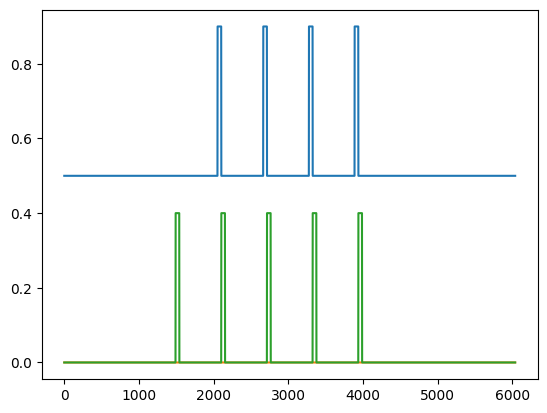

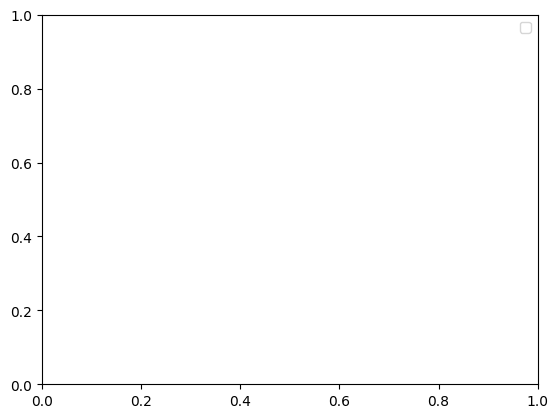

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

def random_pulses(dt, showplots = 0):
    n_events = 5
    hint = 'nohint'
    #period = 0.5+.15*2*(np.random.uniform()-.5);
    period = np.random.uniform()
    ITIb = 0.7 #min. ITI time
    ITIl = 2.0 #mean ITI time
    ITI = ITIb + np.random.exponential(ITIl) #compute ITI for that trial
    fin, fout, fhint = trial_pulse_prediction(dt, period, n_events, ITI, hint)
    if showplots == 1:
        plt.figure()
        plt.plot(fout)
        plt.plot(fhint)
        plt.plot(fin)
        plt.show()
        plt.legend(['Target','Hints','Input'])
    return fin, fout, fhint

def trial_pulse_prediction(dt, period, n_events, ITI, hint):
    output_offset = -0.5
    pulse_width = 0.05 # 0.05
    pulse_height = 0.02 / pulse_width
    output_timeshift = -pulse_width
    pulse_samples = np.round(pulse_width/dt).astype('int')
    
    n_timepoints = np.round((period*n_events+ITI)/dt).astype('int')
    
    
    timepoints = np.arange(0, n_timepoints)*dt

    
    fin = np.zeros((n_timepoints,1))
    fout = np.zeros((n_timepoints,1))
    
    fin[ np.mod(timepoints- ITI/2, period) < pulse_width ,0] = pulse_height
    
    fin[ timepoints < ITI/2 ,0] = 0
    fin[ timepoints > ITI/2 + period*n_events,0] = 0
    
    a = np.where(fin != 0)
    
    a = np.array_split(a[0],5)
    
    
    #concatenate with time delay
    idx = a[4][0]
    #fin = np.concatenate((fin[:idx], np.zeros((200, 1)), fin[idx:]), axis=0)
    #fin = fin[:-200]
    

    num_samples = len(fin)

    #noise = np.random.uniform(low = -0.01, high = 0.01, size=num_samples)
    
    fout = fin - output_offset
    
    fout[timepoints < ITI/2+pulse_width,0] = -output_offset
    fout[0:-1-pulse_samples]=fout[pulse_samples:-1]
    
    # desired output signals and hint signals
    fhint = np.zeros(fin.shape)
    
    #fin = np.add(fin, noise.reshape(-1, 1))
    plt.plot(fin)
    
    
    
    
    return fin, fout, fhint

random_pulses(dt=0.001,showplots=1)


def specific_pulse(dt, showplots = 0, period = 0.4):
    n_events = 5
    hint = 'nohint'
    #period = 0.7 
    ITIb = 0.7 #min. ITI time
    ITIl = 2.0 #mean ITI time
    #print(period)
    ITI = ITIb + np.random.exponential(ITIl) #compute ITI for that trial
    fin, fout, fhint = trial_pulse_prediction(dt, period, n_events, ITI, hint)
    if showplots == 1:
        plt.figure()
        plt.plot(fout)
        plt.plot(fhint)
        plt.plot(fin)
        plt.show()
        plt.legend(['Target','Hints','Input'])
    return fin, fout, fhint


Initializing...
Training network...
Batch 1 of 20, 20 trials: 
....................
Batch 2 of 20, 20 trials: 
....................
Batch 3 of 20, 20 trials: 
....................
Batch 4 of 20, 20 trials: 
....................
Batch 5 of 20, 20 trials: 
....................
Batch 6 of 20, 20 trials: 
....................
Batch 7 of 20, 20 trials: 
....................
Batch 8 of 20, 20 trials: 
....................
Batch 9 of 20, 20 trials: 
....................
Batch 10 of 20, 20 trials: 
....................
Batch 11 of 20, 20 trials: 
....................
Batch 12 of 20, 20 trials: 
....................
Batch 13 of 20, 20 trials: 
....................
Batch 14 of 20, 20 trials: 
....................
Batch 15 of 20, 20 trials: 
....................
Batch 16 of 20, 20 trials: 
....................
Batch 17 of 20, 20 trials: 
....................
Batch 18 of 20, 20 trials: 
....................
Batch 19 of 20, 20 trials: 
....................
Batch 20 of 20, 20 trials: 
..............

[(array([[ 0.00315461],
         [-0.00449768],
         [-0.00813736],
         ...,
         [ 0.0018231 ],
         [-0.00093145],
         [-0.00983185]]),
  array([[0.5],
         [0.5],
         [0.5],
         ...,
         [0.5],
         [0.5],
         [0.5]]),
  array([[0.49909767],
         [0.49944645],
         [0.4996688 ],
         ...,
         [0.50216194],
         [0.50208312],
         [0.50247148]])),
 (array([[ 0.00958506],
         [ 0.00943791],
         [ 0.00623263],
         ...,
         [-0.00573942],
         [-0.00463767],
         [-0.00954942]]),
  array([[0.5],
         [0.5],
         [0.5],
         ...,
         [0.5],
         [0.5],
         [0.5]]),
  array([[0.50160871],
         [0.50137036],
         [0.50157215],
         ...,
         [0.51408738],
         [0.51436285],
         [0.51480776]])),
 (array([[-0.00369386],
         [-0.0036006 ],
         [-0.00022604],
         ...,
         [ 0.0086558 ],
         [ 0.00777737],
         [-0

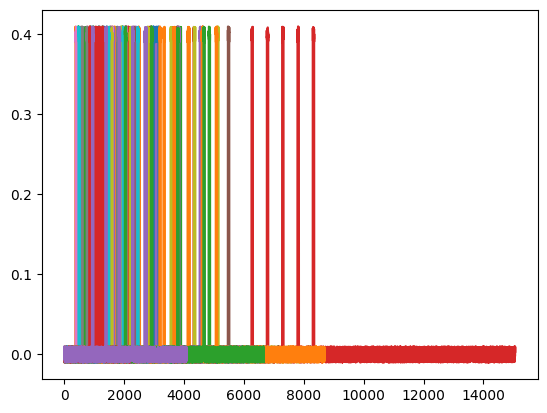

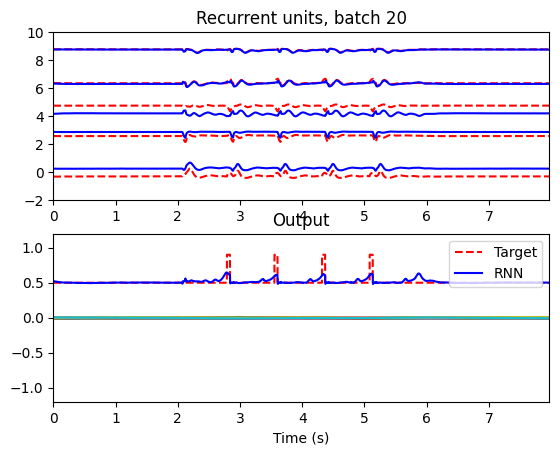

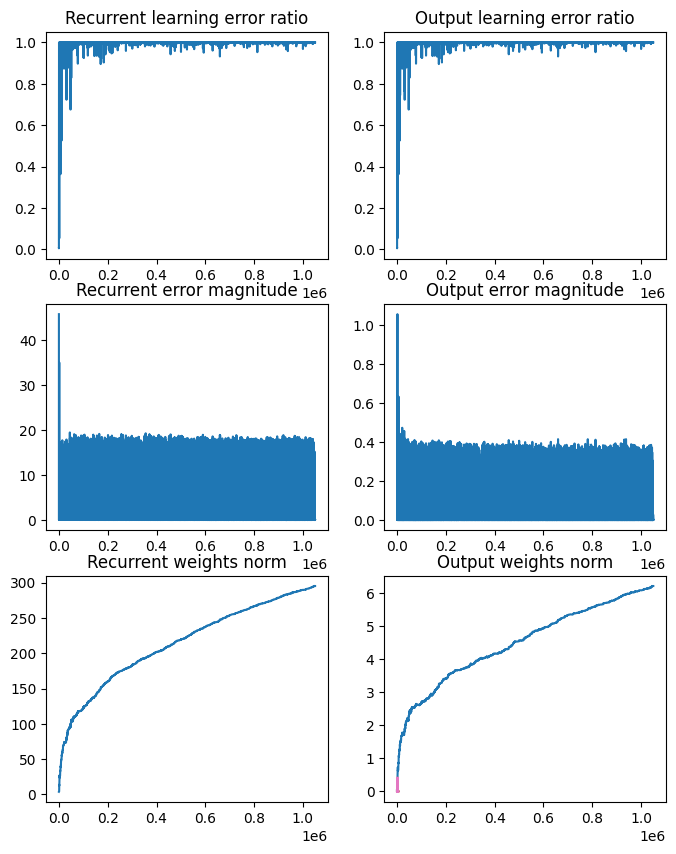

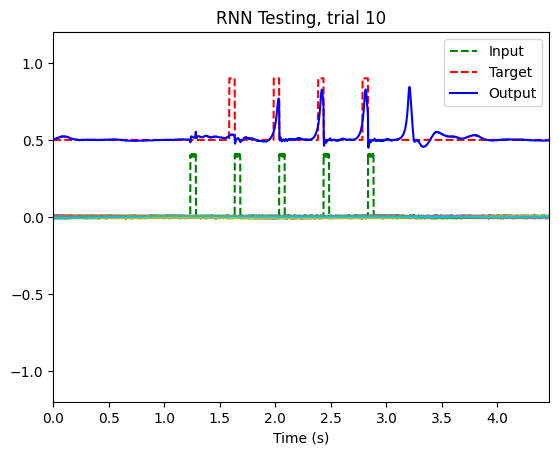

In [32]:
import importlib
import FF_Demo
importlib.reload(FF_Demo)
#%load_ext line_profiler

p = FF_Demo.create_parameters(dt=0.001)
p['g'] = 1.5 # From paper
p['ff_num_batches'] = 20
p['ff_trials_per_batch'] = 20
p['test_init_trials']= 5
p['bias_scale'] = 0.5
p['ff_alpha'] = 1
p['network_size'] = 2000


(D_inputs, D_targs, D_hints) = random_pulses(dt=p['dt'])[0:3]

rnn = FF_Demo.RNN(p,1,1)

rnn.train(random_pulses, monitor_training=1)

#With line_profiler:
# %lprun -f rnn.train rnn.train(fullforce_oscillation_test, monitor_training=1)

rnn.test(specific_pulse)

Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.017 seconds late
The width of the predicted pulse at half-max is 130.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.019 seconds late
The width of the predicted pulse at half-max is 120.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.015 seconds late
The width of the predicted pulse at half-max is 102.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.007 seconds late
The width of the predicted pulse at half-max is 107.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.001 seconds late
The width of the predicted pulse at half-max is 100.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.001 seconds early
The width of the predicted pulse at half-max is 112.5% the size 

/var/folders/sm/06fq8qt553j0wpvnh8x6ys3h0000gn/T/ipykernel_81620/932245965.py:19: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


....
Testing: 10 trials
..........
The predicted pulse peak is 0.001 seconds early
The width of the predicted pulse at half-max is 150.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.05 seconds early
The width of the predicted pulse at half-max is 227.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.079 seconds late
The width of the predicted pulse at half-max is 382.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.067 seconds late
The width of the predicted pulse at half-max is 307.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.008 seconds late
The width of the predicted pulse at half-max is 287.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.028 seconds early
The width of the predicted pulse at half-max is 322.5% the size of input
Ini

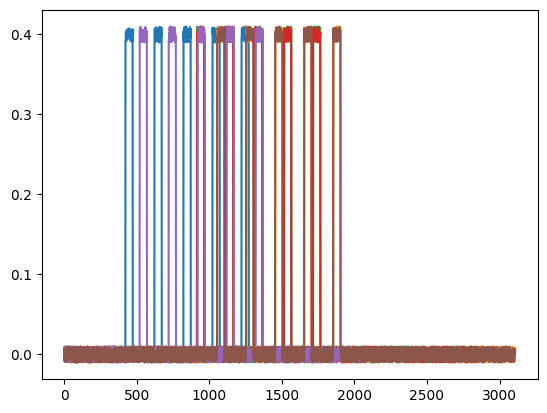

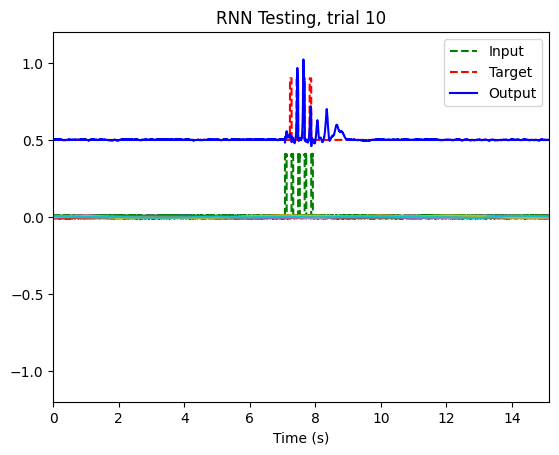

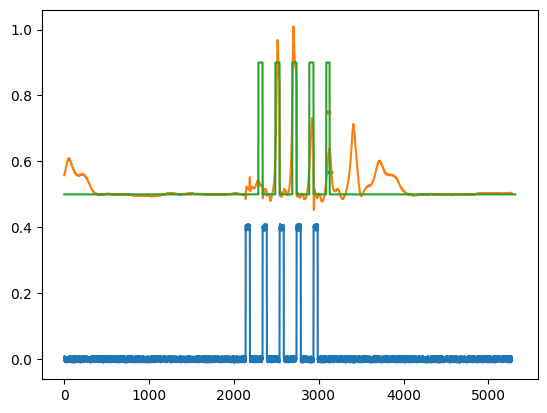

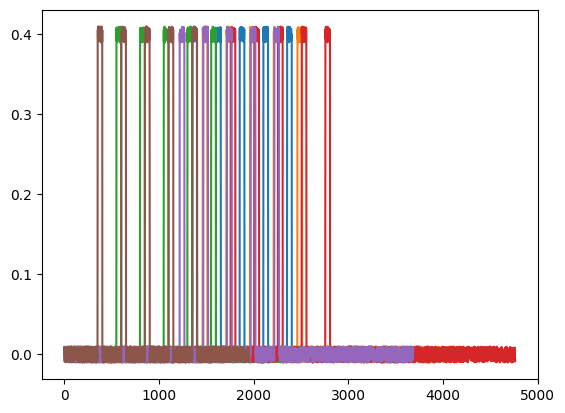

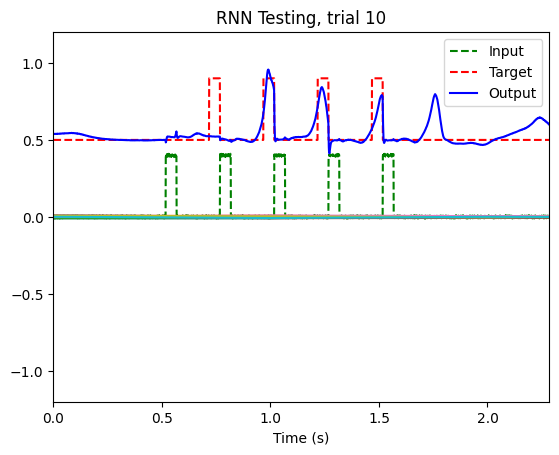

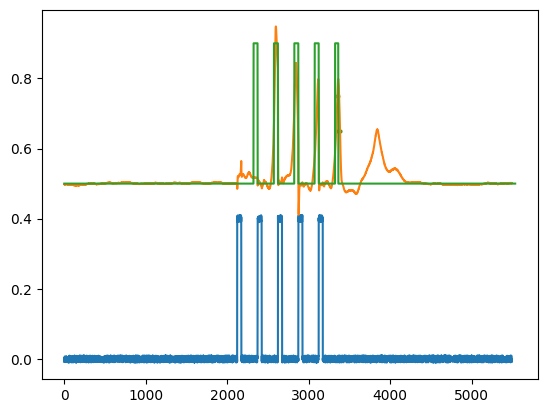

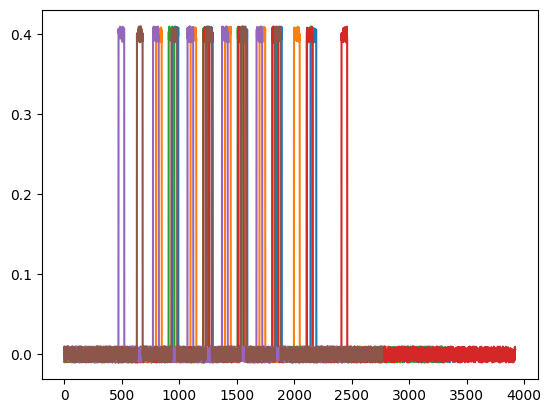

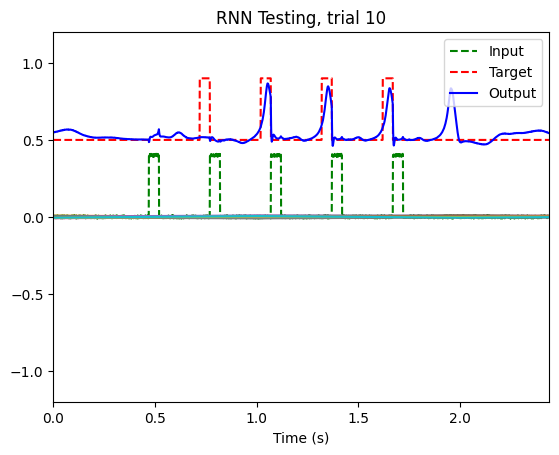

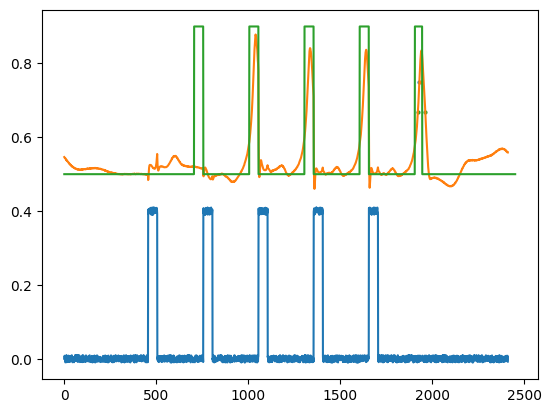

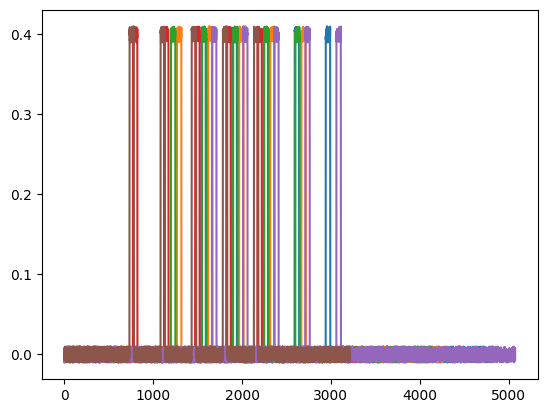

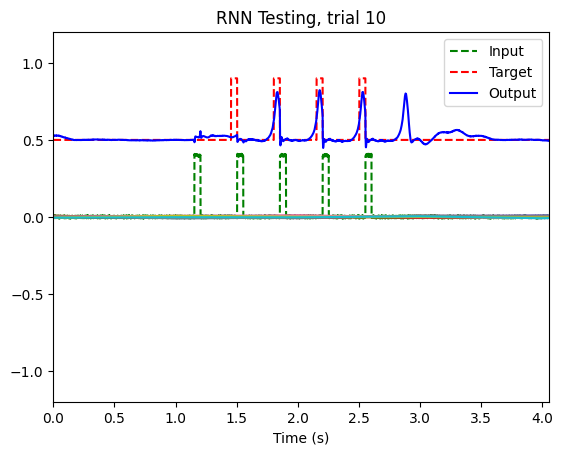

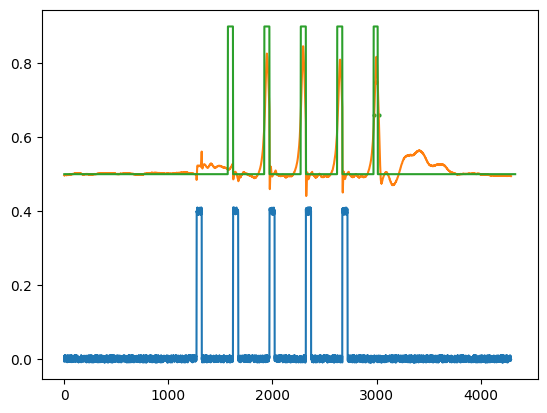

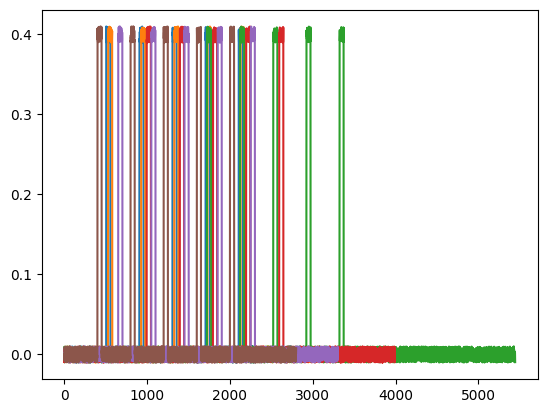

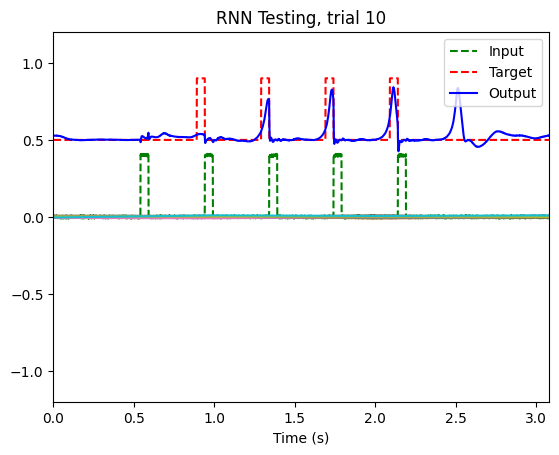

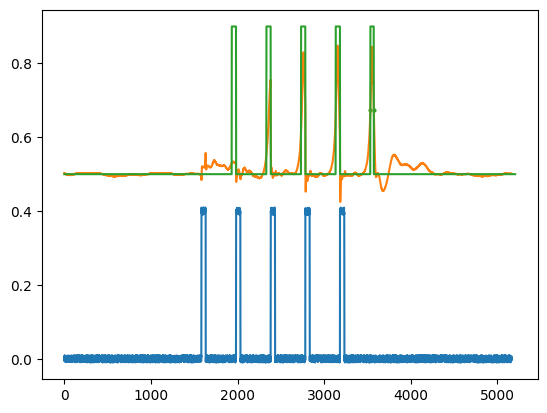

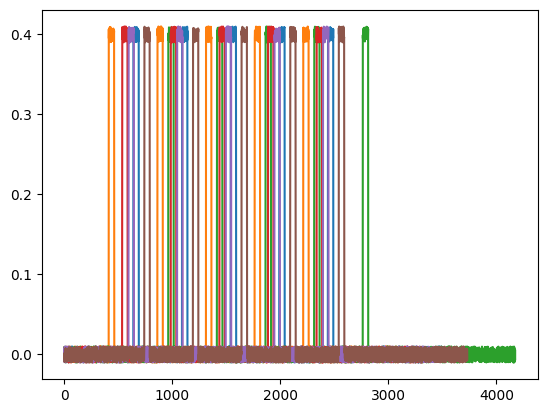

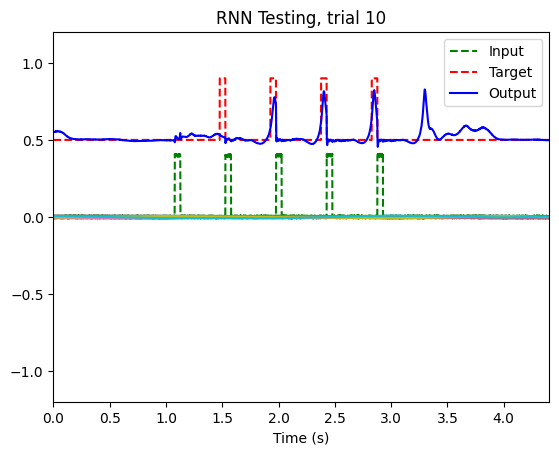

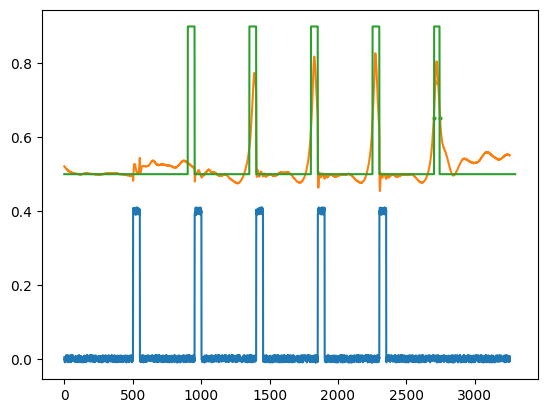

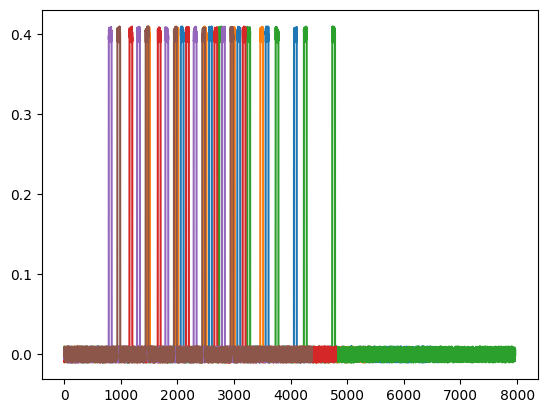

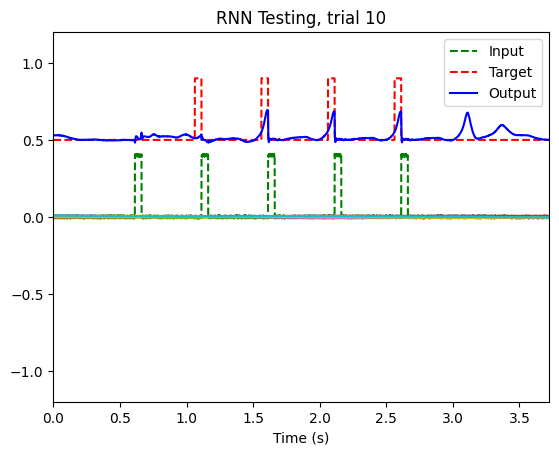

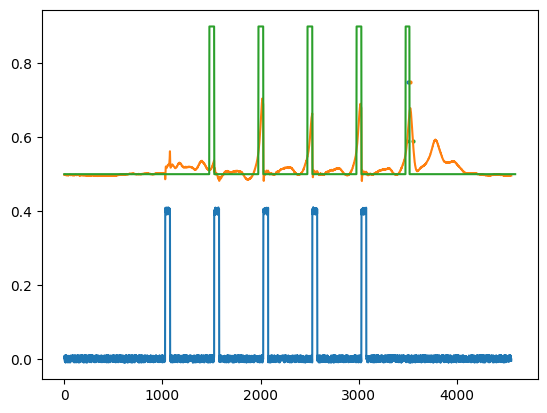

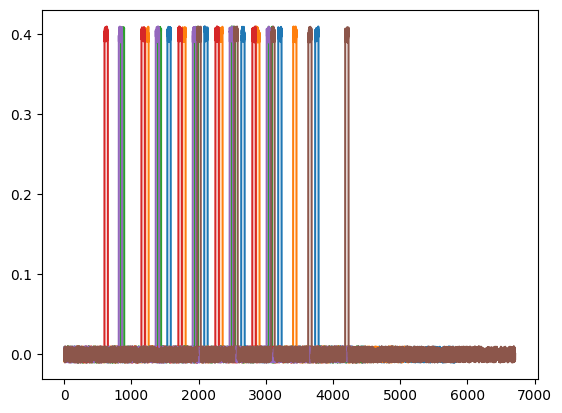

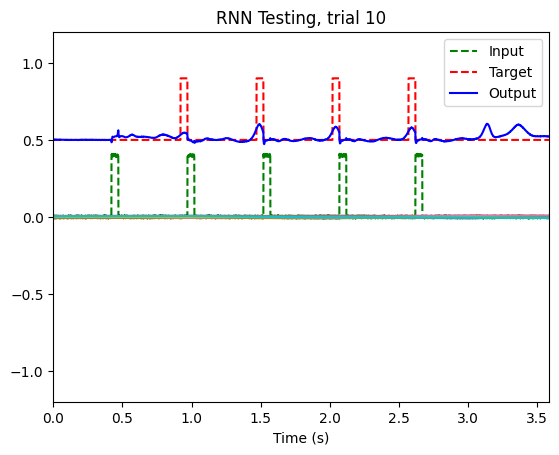

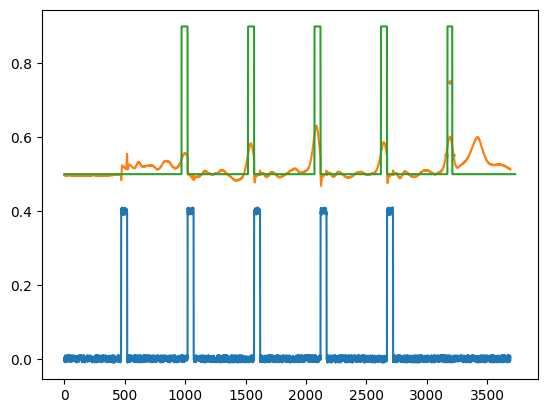

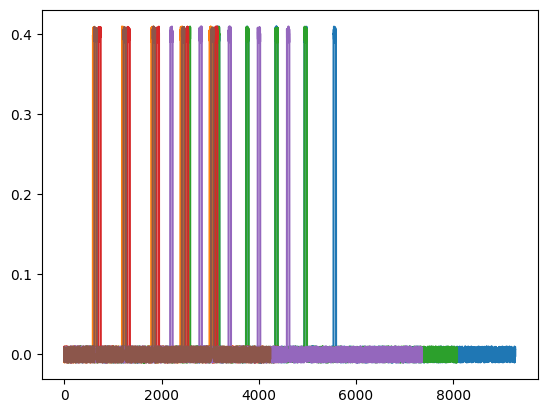

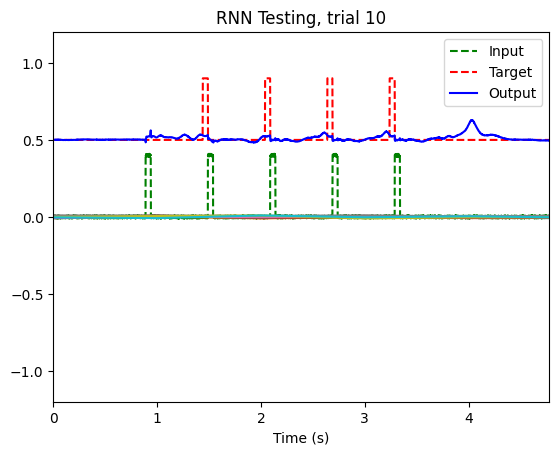

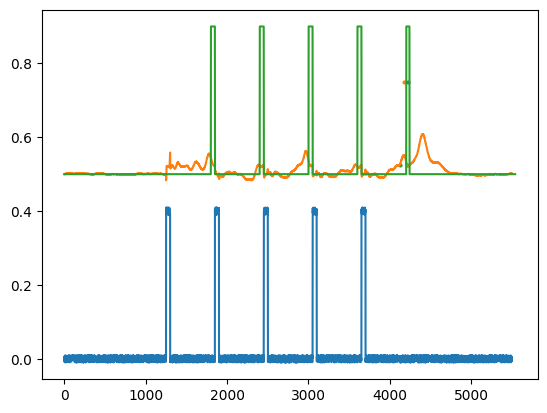

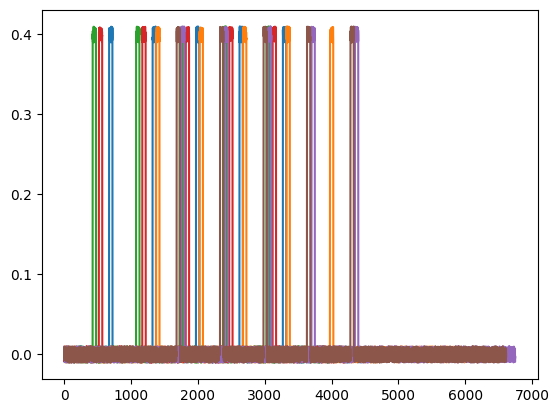

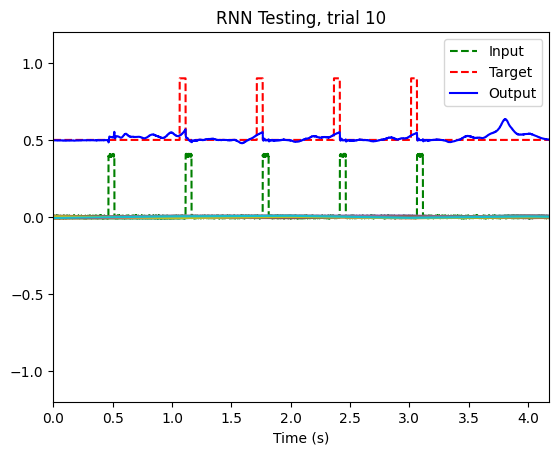

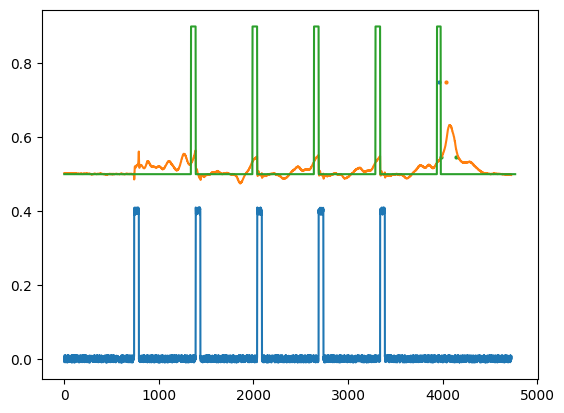

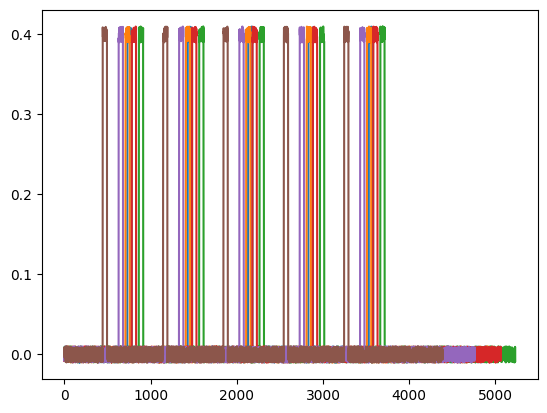

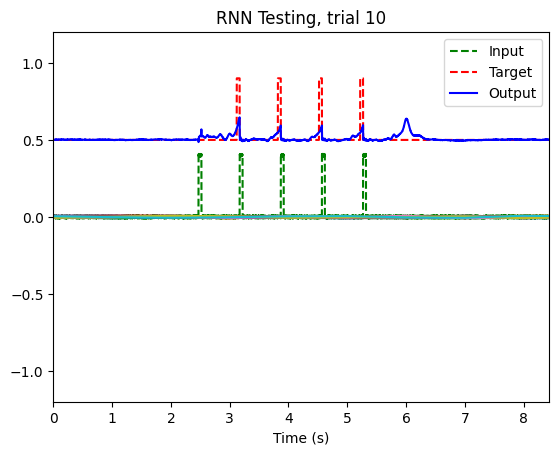

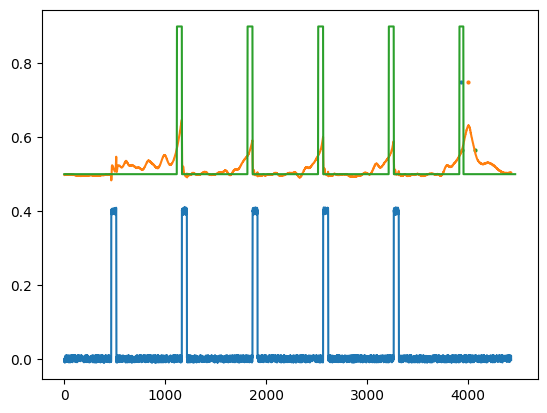

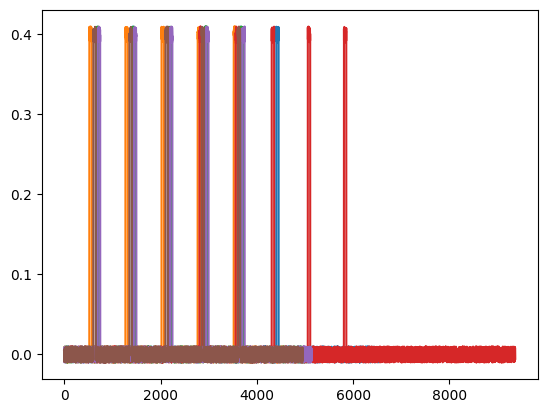

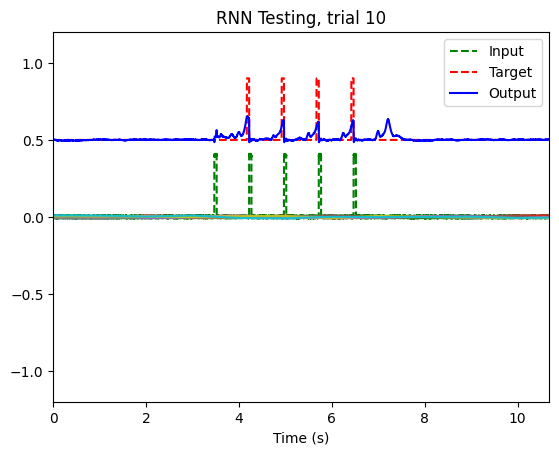

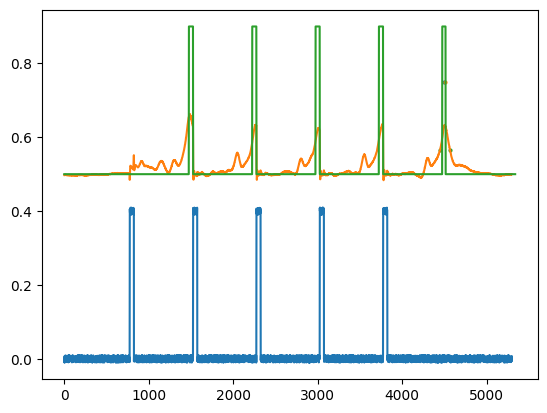

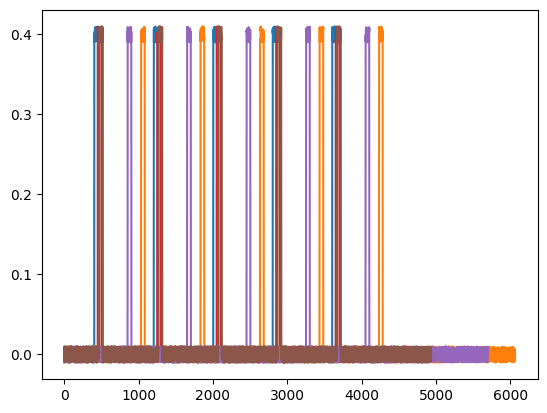

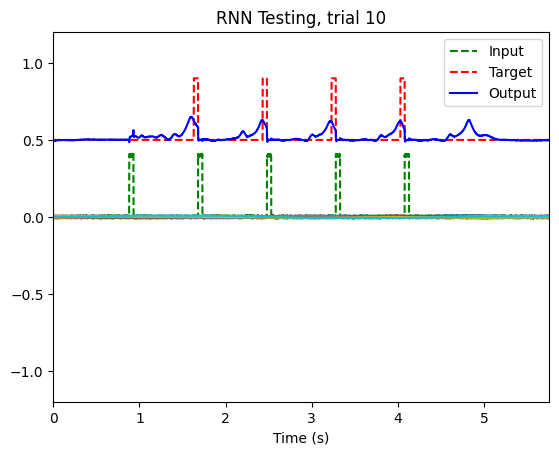

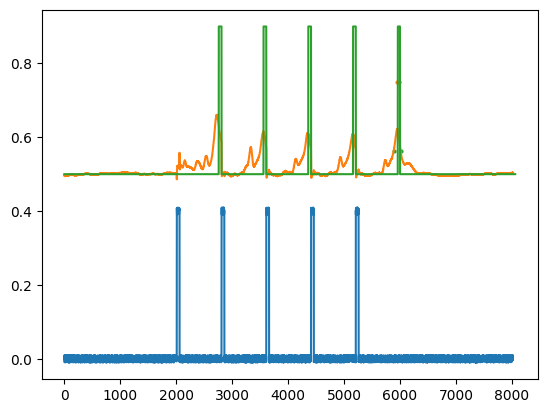

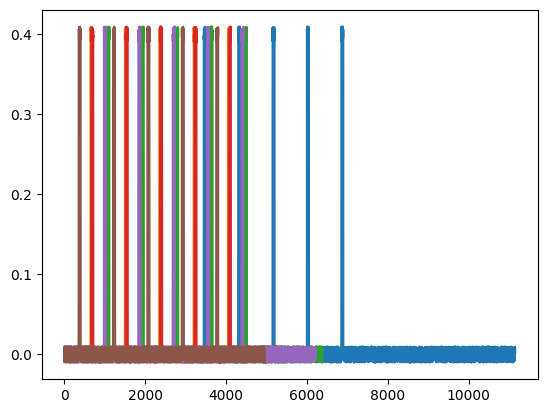

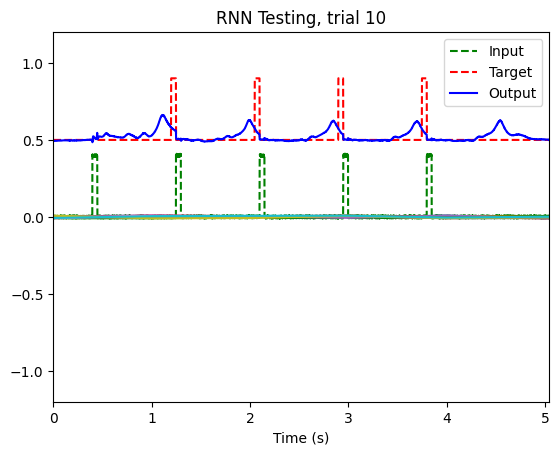

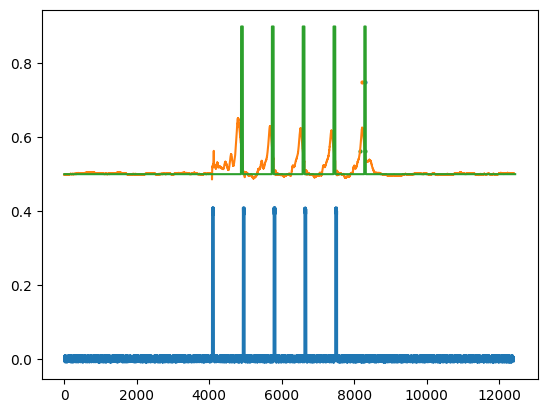

<Figure size 640x480 with 0 Axes>

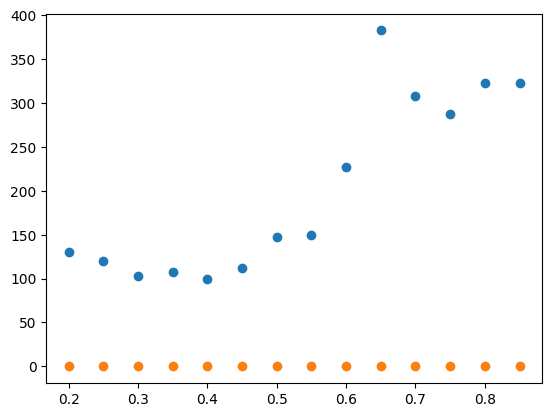

In [33]:
import pickle
import FF_Demo
import numpy as np

#loads saved model from the same directory
#rnn = pickle.load(open("model16-2000-full-period-20-20-0.5",'rb'))

#defines arrays to store errors for each period
half_max_width = [] 
position_error = []

#defines range for testing periods
range_array = np.arange(0.2,0.9,0.05)

#loop to test multiple periods
for item in range_array:
    #calls test function from FF_demo.py on different periods
    x = rnn.test(specific_pulse, period = item)
    plt.figure()

    #stores the target output and model output
    fin = x[0][0];ftarg = x[0][1]; fout = x[0][2]

    #finds each pulse in the target output and stores the indicies in groups of 5
    a = np.where(ftarg >= 0.7)
    a = np.array_split(a[0],5)

    #finds the location of the predicted pulse and inserts it
    idx = a[4][0] + abs(a[4][0] -  a[3][0])
    ftarg = np.concatenate((ftarg[:idx], np.full_like(np.zeros((40, 1)),0.9), ftarg[idx:]), axis=0)
    
    #plots the output with the predicted pulse
    plt.plot(fin)
    plt.plot(fout)
    plt.plot(ftarg)
    
    #defines positions: check range = how far left and right values are checked
    check_range = 100 
    check_left = idx - check_range
    check_right = idx + check_range
    check_slice = fout[check_left:check_right]
    
    #find the maximal value of model output
    max_val = np.max(check_slice)
    
    #finds index of maximal value of model output relative to slice
    max_out_near_predict = np.argmax(check_slice)
    
    #absolute index in fout of maxical value
    model_max_index = max_out_near_predict + check_left
    
    #target index of predict pulse
    predict = idx + 20
    
    #plots target prediction point and model prediction point
    plt.scatter(predict, 0.75,4)
    plt.scatter(model_max_index,0.75,4)
    
    #calculates the time error in seconds
    time_from_target = 0.001*((check_left+max_out_near_predict)-(predict))

    #reports time error
    if time_from_target < 0: 
        print(f"The predicted pulse peak is {abs(time_from_target)} seconds early")
    else:
        print(f"The predicted pulse peak is {time_from_target} seconds late")
        
    #stores time error
    position_error.append(time_from_target)
    
    #check index centred on model predict
    check_model_left = model_max_index - check_range
    
    half_max = 0.25+max_val/2
    
    #calculates the index for 1/2 max out put for left side and right side of the pulse
    pulse_left = check_model_left + np.abs(fout[check_model_left:model_max_index] - half_max).argmin()
    pulse_right = model_max_index + np.abs(fout[model_max_index:model_max_index+100] - half_max).argmin()

    #plots the 1/2 max on the left and right size
    plt.scatter([pulse_left,pulse_right], [half_max,half_max],4)
    #plt.scatter(pulse_right, 0.25+max_val/2,4)

    #calculates size of model predict relative to target predict
    pulse_size_error =  100*abs(pulse_left-pulse_right)/40

    print(f"The width of the predicted pulse at half-max is {pulse_size_error}% the size of input")
    
    #stores size of model predict
    half_max_width.append(pulse_size_error)
    plt.figure()



plt.figure()
plt.scatter(range_array, half_max_width)
plt.scatter(range_array, position_error)
plt.show()
#print(error_to_plot)

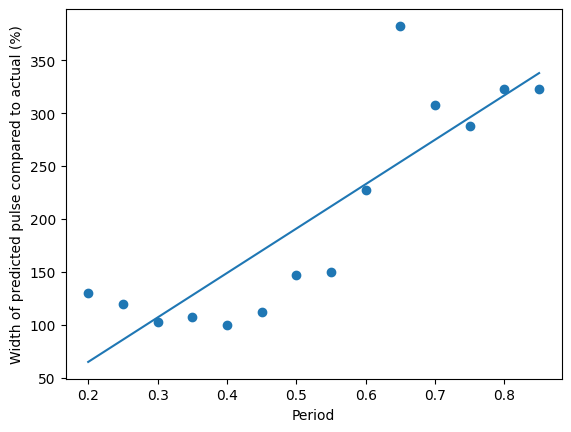

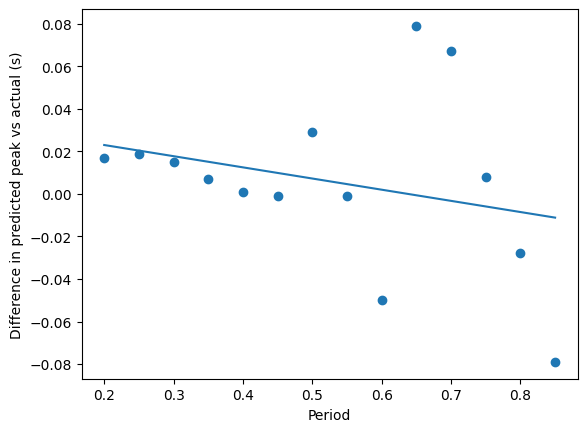

In [34]:
#from sklearn.metrics import r2_score

a,b = np.polyfit(range_array, half_max_width, 1)

plt.figure()
plt.scatter(range_array, half_max_width)
plt.plot(range_array, a*range_array+b)
plt.ylabel("Width of predicted pulse compared to actual (%)")
plt.xlabel("Period")

a,b = np.polyfit(range_array, position_error, 1)

plt.figure()
plt.ylabel("Difference in predicted peak vs actual (s)")
plt.xlabel("Period")
plt.scatter(range_array, position_error)
plt.plot(range_array, a*range_array+b)
plt.show()


In [35]:
import pickle

filename = "model21-noisy-input-2000-full-period-20-20-0.5"
pickle.dump(rnn, open(filename, 'wb'))

Initializing.....
Testing: 10 trials
........

KeyboardInterrupt: 

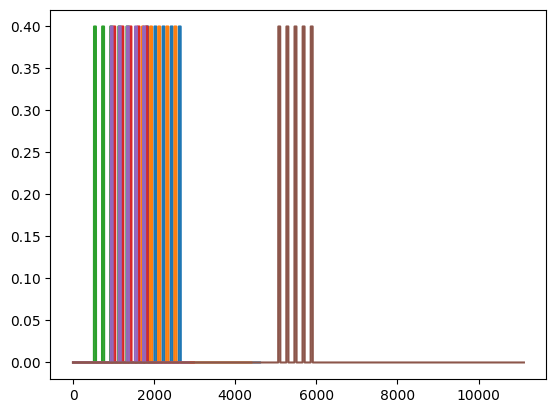

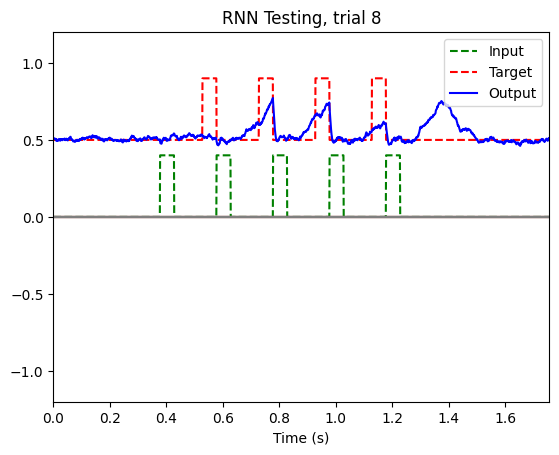

In [2]:
import pickle
import FF_Demo
import numpy as np

#loads saved model from the same directory
rnn = pickle.load(open("model22-noise_std-0.1-2000-full-period-20-20-0.5"
,'rb'))

#defines arrays to store errors for each period
half_max_width = [] 
position_error = []

#defines range for testing periods
range_array = np.arange(0.2,0.9,0.05)

#loop to test multiple periods
for item in range_array:
    #calls test function from FF_demo.py on different periods
    x = rnn.test(specific_pulse, period = item)
    plt.figure()

    #stores the target output and model output
    fin = x[0][0];ftarg = x[0][1]; fout = x[0][2]

    #finds each pulse in the target output and stores the indicies in groups of 5
    a = np.where(ftarg >= 0.7)
    a = np.array_split(a[0],5)

    #finds the location of the predicted pulse and inserts it
    idx = a[4][0] + abs(a[4][0] -  a[3][0])
    ftarg = np.concatenate((ftarg[:idx], np.full_like(np.zeros((40, 1)),0.9), ftarg[idx:]), axis=0)
    
    #plots the output with the predicted pulse
    plt.plot(fin)
    plt.plot(fout)
    plt.plot(ftarg)
    
    #defines positions: check range = how far left and right values are checked
    check_range = 100 
    check_left = idx - check_range
    check_right = idx + check_range
    check_slice = fout[check_left:check_right]
    
    #find the maximal value of model output
    max_val = np.max(check_slice)
    
    #finds index of maximal value of model output relative to slice
    max_out_near_predict = np.argmax(check_slice)
    
    #absolute index in fout of maxical value
    model_max_index = max_out_near_predict + check_left
    
    #target index of predict pulse
    predict = idx + 20
    
    #plots target prediction point and model prediction point
    plt.scatter(predict, 0.75,4)
    plt.scatter(model_max_index,0.75,4)
    
    #calculates the time error in seconds
    time_from_target = 0.001*((check_left+max_out_near_predict)-(predict))

    #reports time error
    if time_from_target < 0: 
        print(f"The predicted pulse peak is {abs(time_from_target)} seconds early")
    else:
        print(f"The predicted pulse peak is {time_from_target} seconds late")
        
    #stores time error
    position_error.append(time_from_target)
    
    #check index centred on model predict
    check_model_left = model_max_index - check_range
    
    half_max = 0.25+max_val/2
    
    #calculates the index for 1/2 max out put for left side and right side of the pulse
    pulse_left = check_model_left + np.abs(fout[check_model_left:model_max_index] - half_max).argmin()
    pulse_right = model_max_index + np.abs(fout[model_max_index:model_max_index+100] - half_max).argmin()

    #plots the 1/2 max on the left and right size
    plt.scatter([pulse_left,pulse_right], [half_max,half_max],4)
    #plt.scatter(pulse_right, 0.25+max_val/2,4)

    #calculates size of model predict relative to target predict
    pulse_size_error =  100*abs(pulse_left-pulse_right)/40

    print(f"The width of the predicted pulse at half-max is {pulse_size_error}% the size of input")
    
    #stores size of model predict
    half_max_width.append(pulse_size_error)
    plt.figure()



plt.figure()
plt.scatter(range_array, half_max_width)
plt.scatter(range_array, position_error)
plt.show()
#print(error_to_plot)

Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.028 seconds late
The width of the predicted pulse at half-max is 127.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.036000000000000004 seconds late
The width of the predicted pulse at half-max is 330.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.016 seconds late
The width of the predicted pulse at half-max is 135.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.048 seconds late
The width of the predicted pulse at half-max is 132.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.023 seconds late
The width of the predicted pulse at half-max is 175.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.057 seconds late
The width of the predicted pulse at half-max is 31

C:\Users\Manav\AppData\Local\Temp\ipykernel_4316\1181687683.py:19: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


....
Testing: 10 trials
..........
The predicted pulse peak is 0.015 seconds late
The width of the predicted pulse at half-max is 212.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.091 seconds early
The width of the predicted pulse at half-max is 175.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.07200000000000001 seconds early
The width of the predicted pulse at half-max is 167.5% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.029 seconds late
The width of the predicted pulse at half-max is 250.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.011 seconds early
The width of the predicted pulse at half-max is 315.0% the size of input
Initializing.....
Testing: 10 trials
..........
The predicted pulse peak is 0.065 seconds early
The width of the predicted pulse at half-max is 285.0% the s

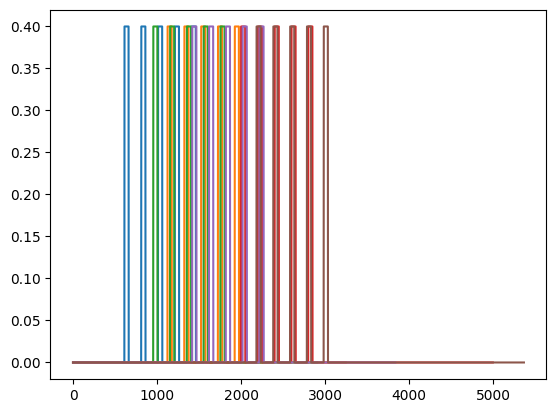

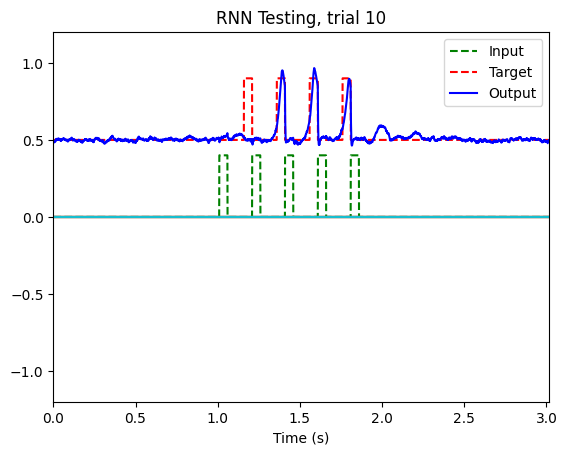

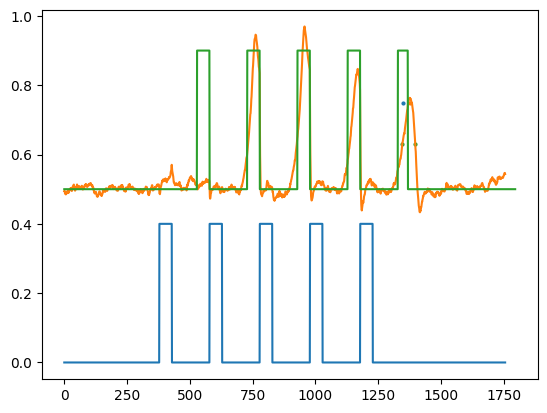

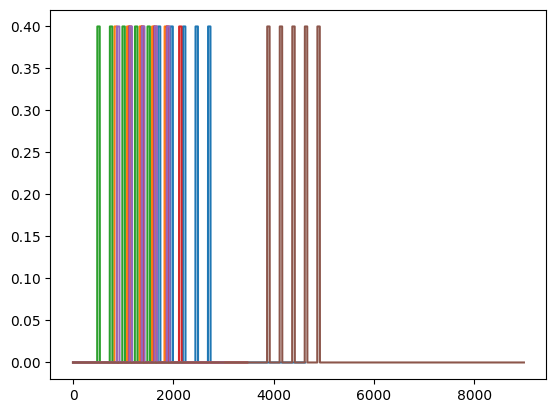

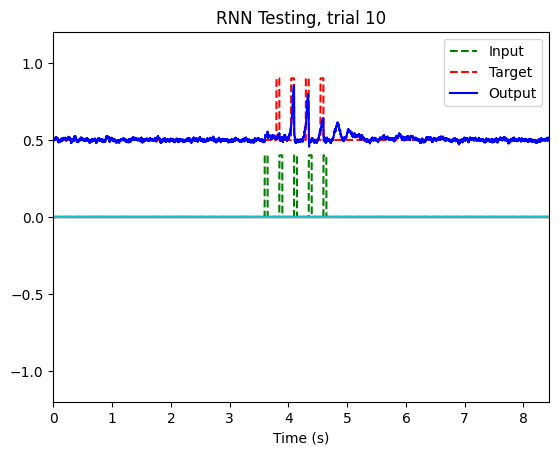

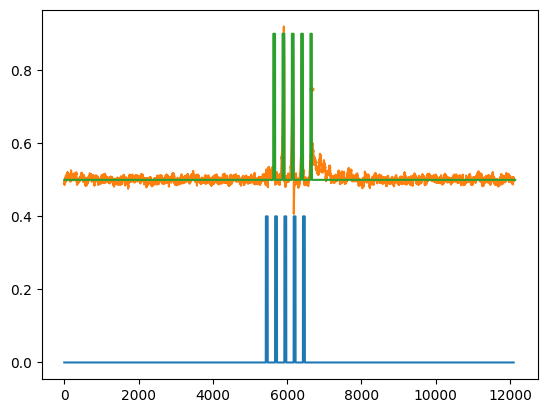

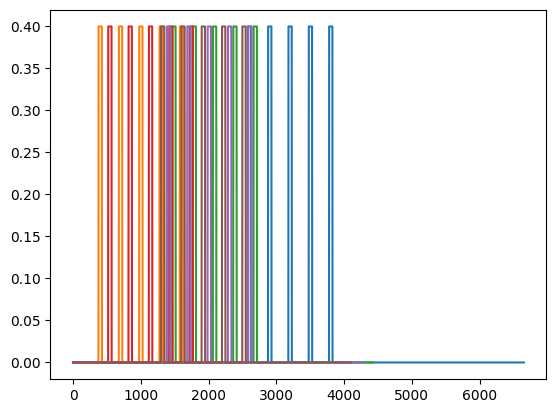

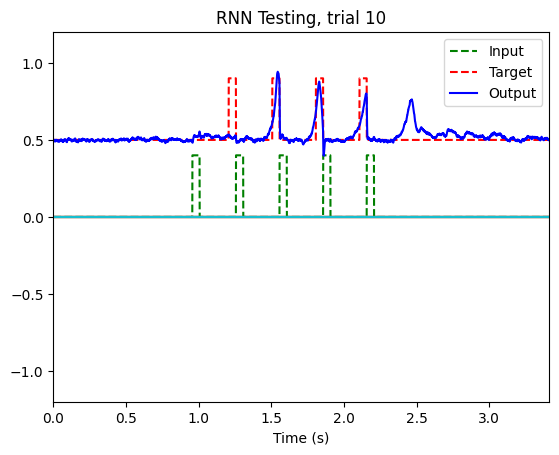

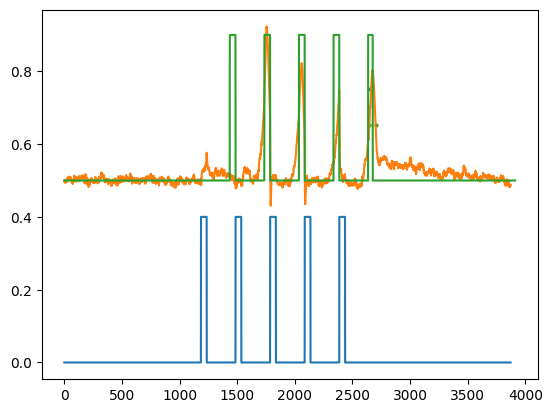

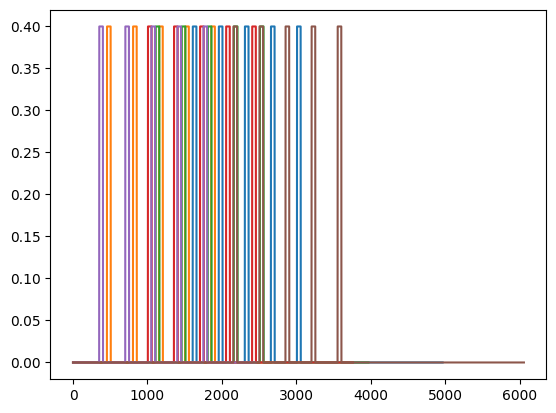

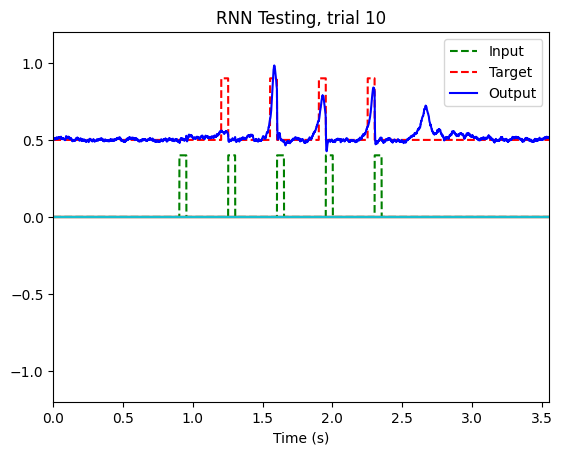

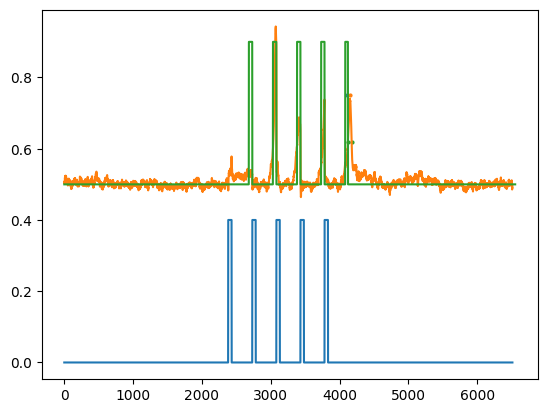

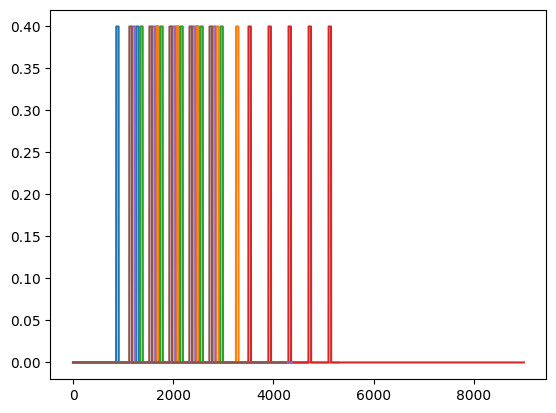

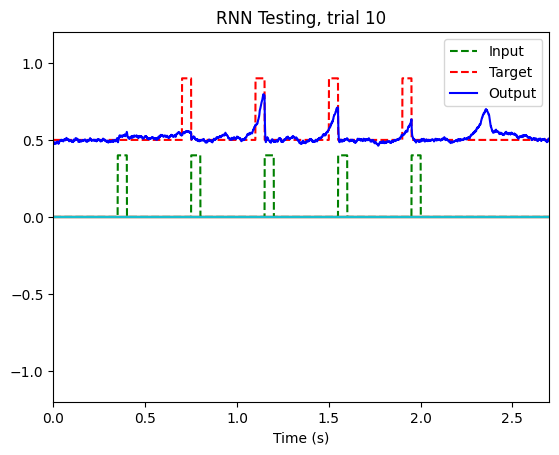

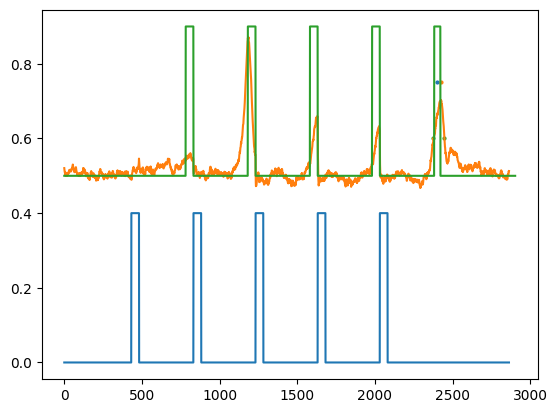

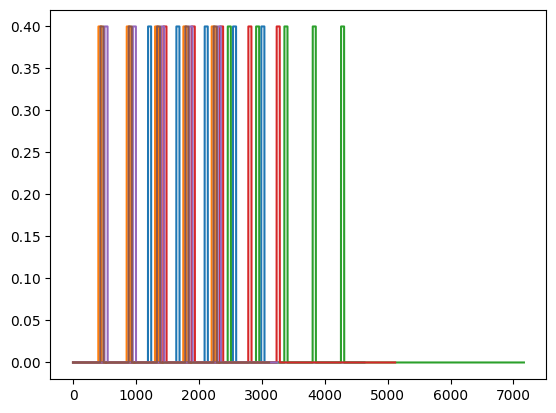

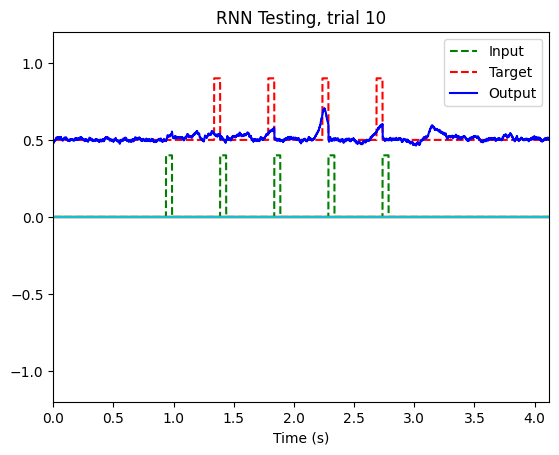

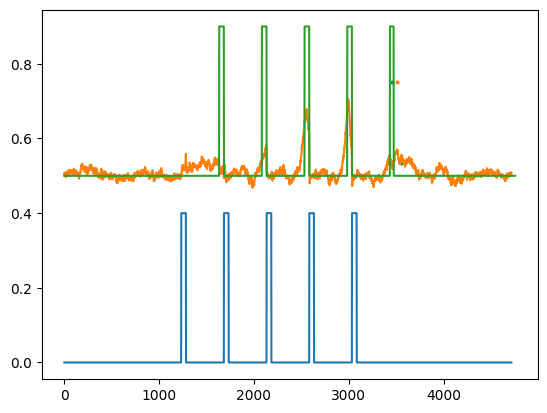

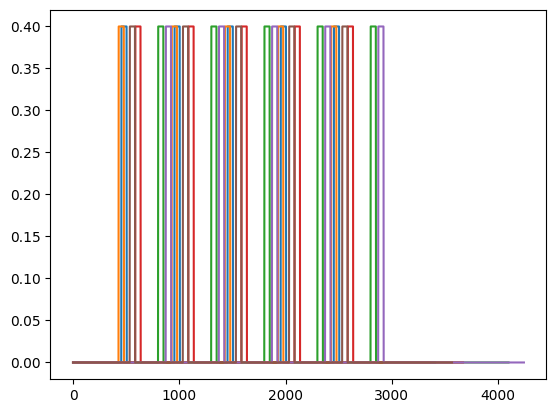

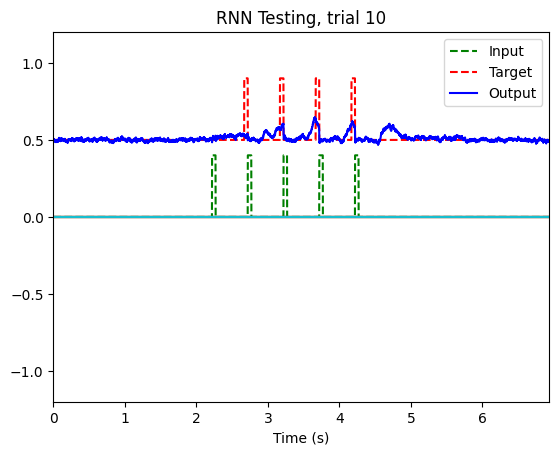

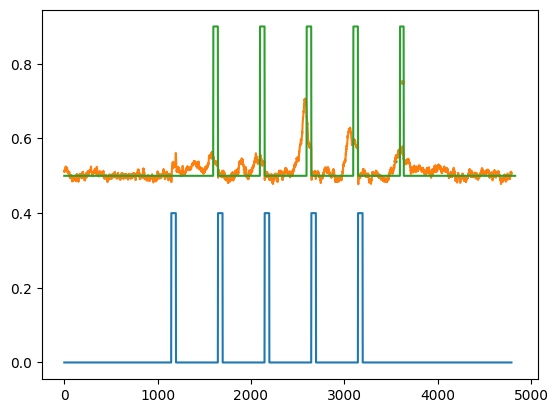

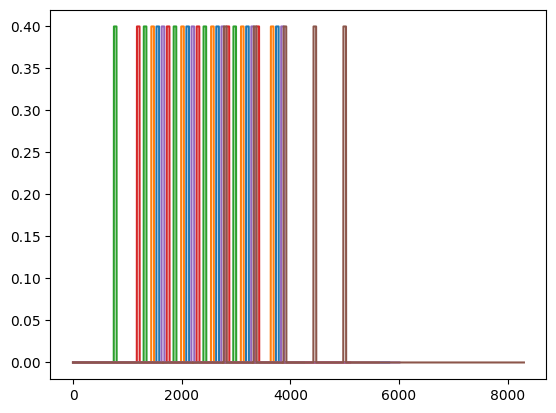

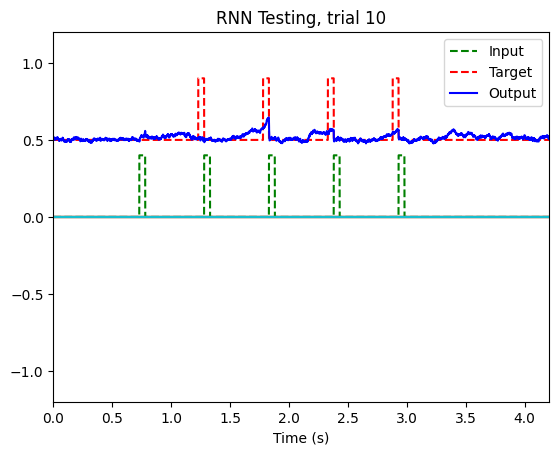

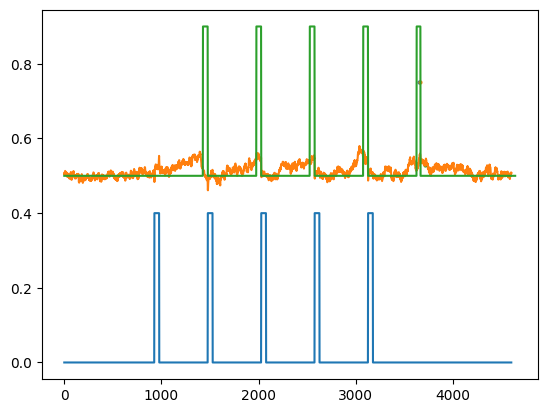

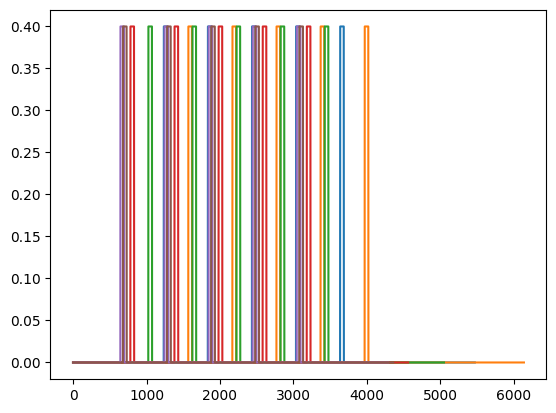

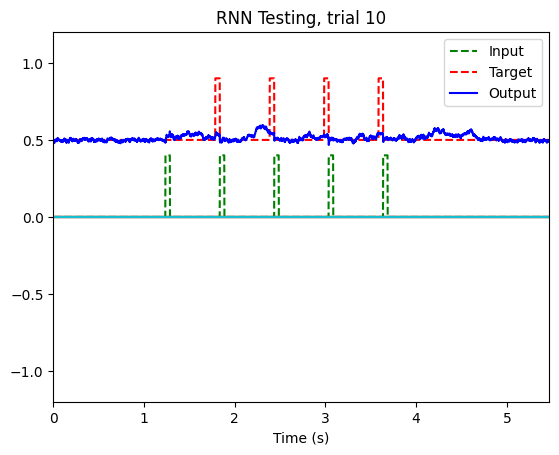

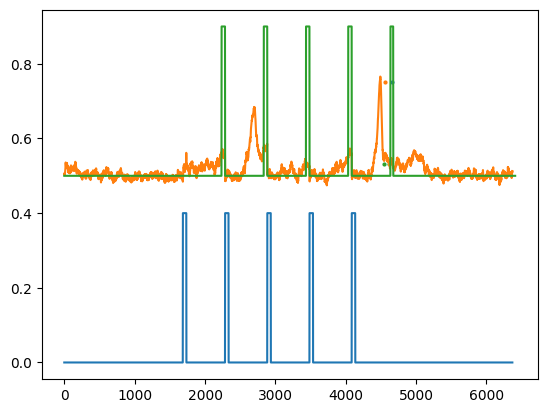

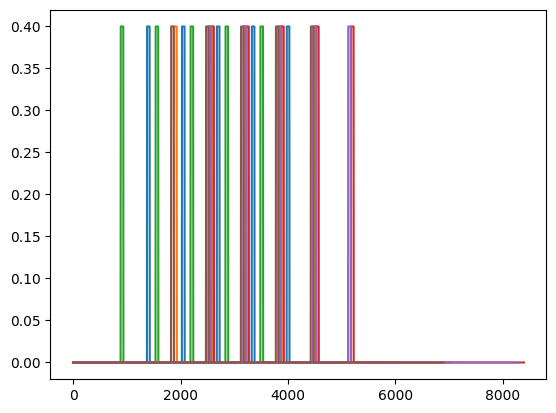

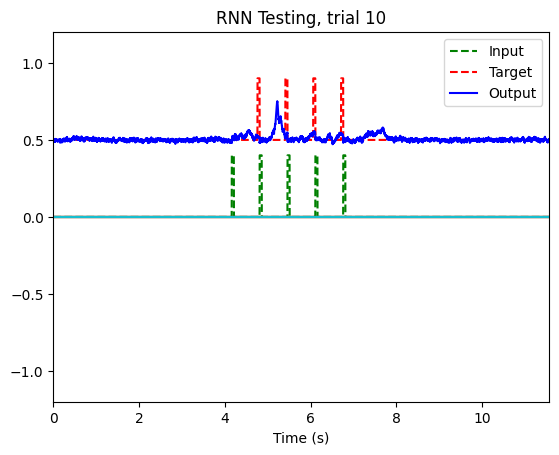

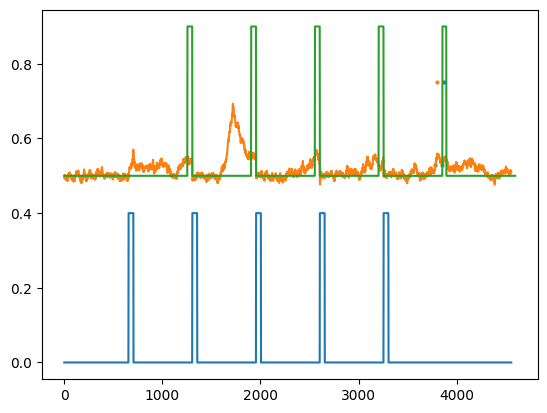

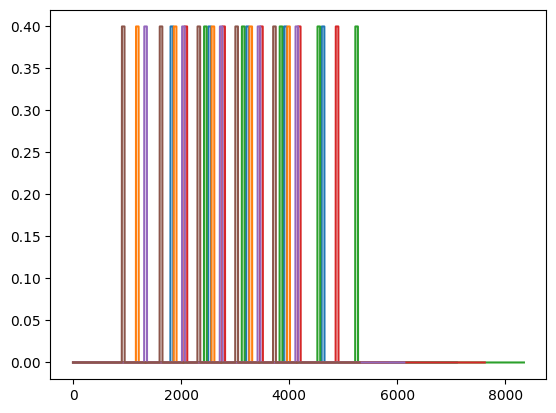

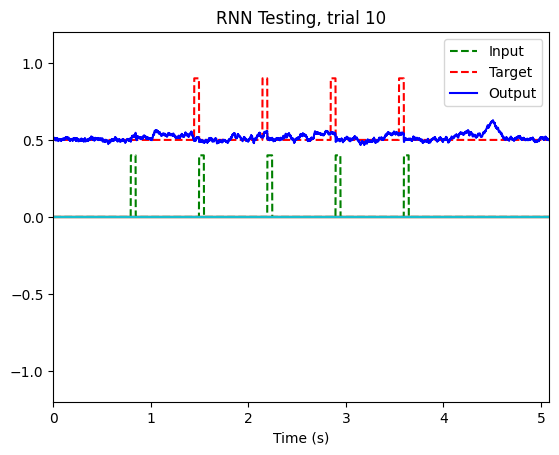

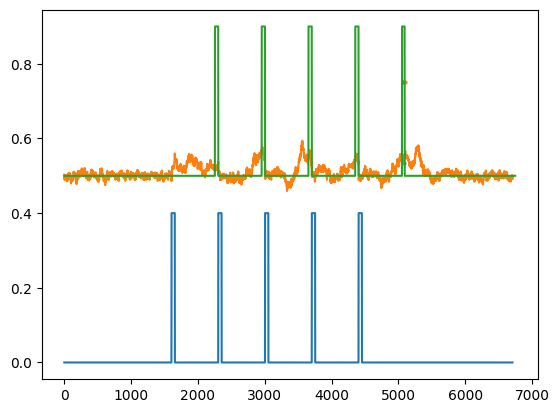

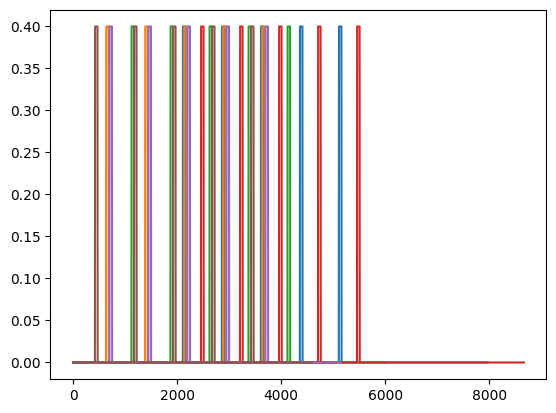

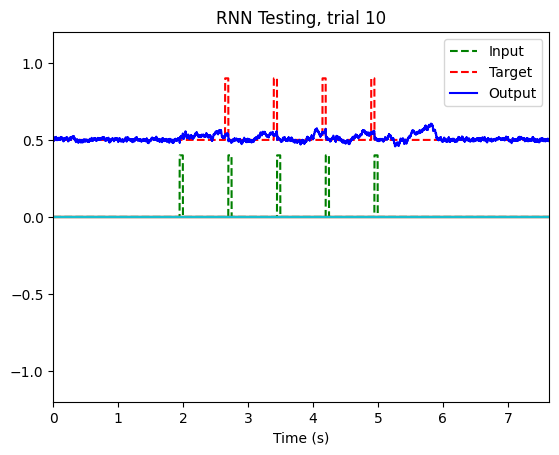

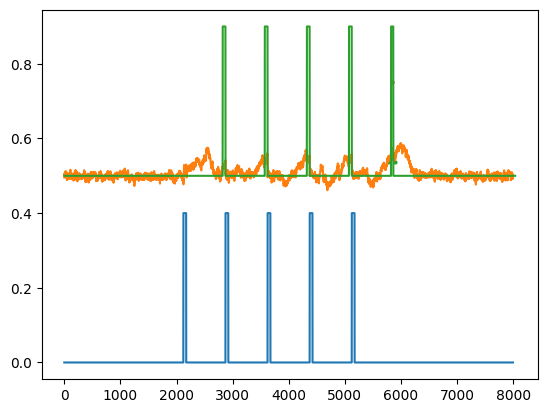

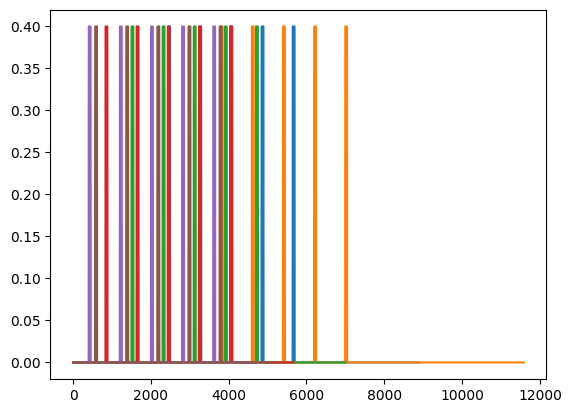

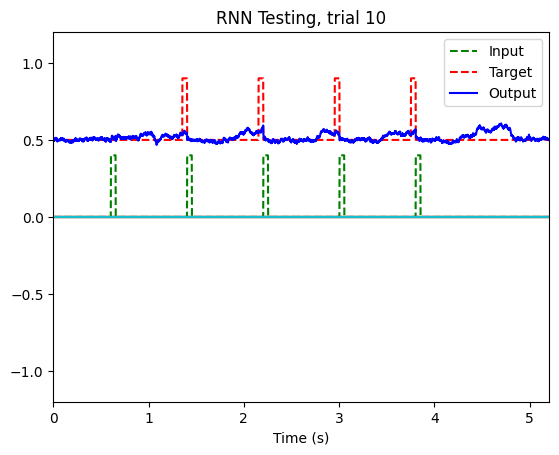

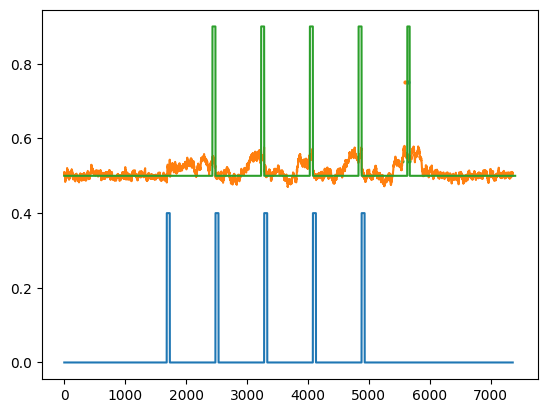

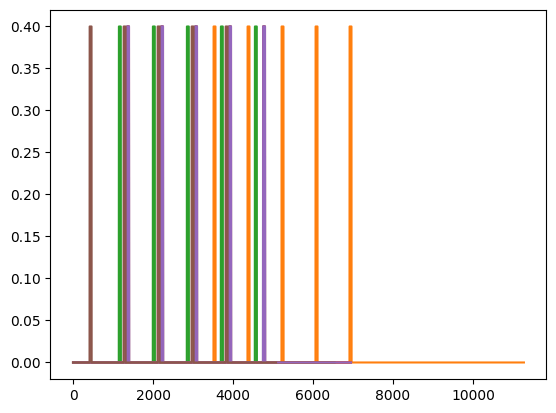

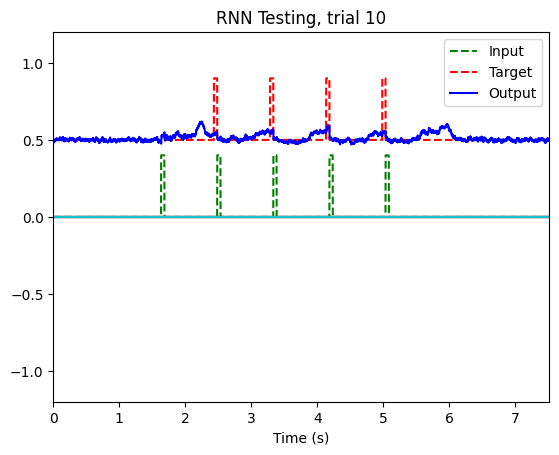

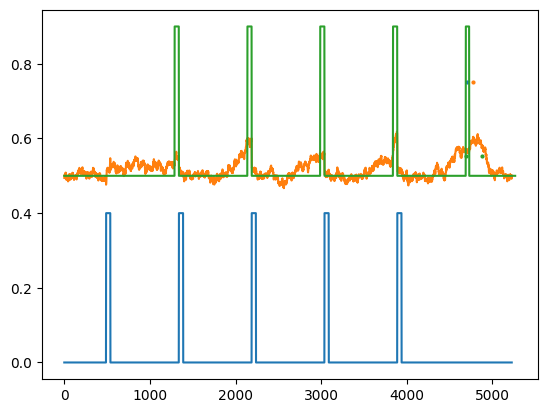

<Figure size 640x480 with 0 Axes>

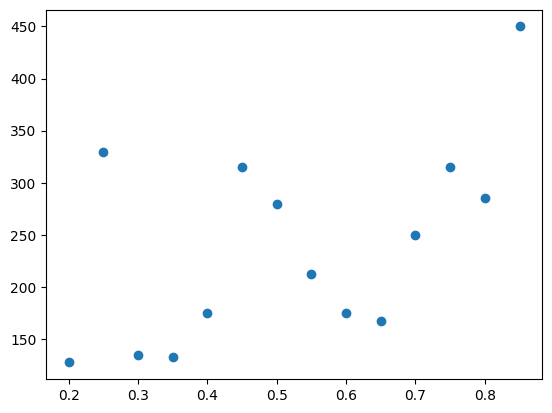

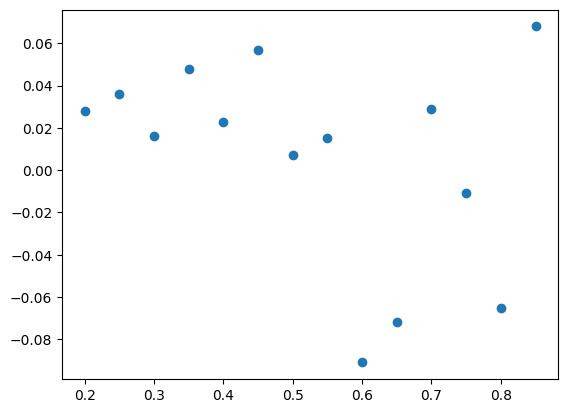

In [3]:

import pickle
import FF_Demo
import numpy as np

#loads saved model from the same directory
rnn = pickle.load(open("model22-noise_std-0.01-2000-full-period-20-20-0.5",'rb'))

#defines arrays to store errors for each period
half_max_width = [] 
position_error = []

#defines range for testing periods
range_array = np.arange(0.2,0.9,0.05)

#loop to test multiple periods
for item in range_array:
    #calls test function from FF_demo.py on different periods
    x = rnn.test(specific_pulse, period = item)
    plt.figure()

    #stores the target output and model output
    fin = x[0][0];ftarg = x[0][1]; fout = x[0][2]

    #finds each pulse in the target output and stores the indicies in groups of 5
    a = np.where(ftarg >= 0.7)
    a = np.array_split(a[0],5)

    #finds the location of the predicted pulse and inserts it
    idx = a[4][0] + abs(a[4][0] -  a[3][0])
    ftarg = np.concatenate((ftarg[:idx], np.full_like(np.zeros((40, 1)),0.9), ftarg[idx:]), axis=0)
    
    #plots the output with the predicted pulse
    plt.plot(fin)
    plt.plot(fout)
    plt.plot(ftarg)
    
    #defines positions: check range = how far left and right values are checked
    check_range = 100 
    check_left = idx - check_range
    check_right = idx + check_range
    check_slice = fout[check_left:check_right]
    
    #find the maximal value of model output
    max_val = np.max(check_slice)
    
    #finds index of maximal value of model output relative to slice
    max_out_near_predict = np.argmax(check_slice)
    
    #absolute index in fout of maxical value
    model_max_index = max_out_near_predict + check_left
    
    #target index of predict pulse
    predict = idx + 20
    
    #plots target prediction point and model prediction point
    plt.scatter(predict, 0.75,4)
    plt.scatter(model_max_index,0.75,4)
    
    #calculates the time error in seconds
    time_from_target = 0.001*((check_left+max_out_near_predict)-(predict))

    #reports time error
    if time_from_target < 0: 
        print(f"The predicted pulse peak is {abs(time_from_target)} seconds early")
    else:
        print(f"The predicted pulse peak is {time_from_target} seconds late")
        
    #stores time error
    position_error.append(time_from_target)
    
    #check index centred on model predict
    check_model_left = model_max_index - check_range
    
    half_max = 0.25+max_val/2
    
    #calculates the index for 1/2 max out put for left side and right side of the pulse
    pulse_left = check_model_left + np.abs(fout[check_model_left:model_max_index] - half_max).argmin()
    pulse_right = model_max_index + np.abs(fout[model_max_index:model_max_index+100] - half_max).argmin()

    #plots the 1/2 max on the left and right size
    plt.scatter([pulse_left,pulse_right], [half_max,half_max],4)
    #plt.scatter(pulse_right, 0.25+max_val/2,4)

    #calculates size of model predict relative to target predict
    pulse_size_error =  100*abs(pulse_left-pulse_right)/40

    print(f"The width of the predicted pulse at half-max is {pulse_size_error}% the size of input")
    
    #stores size of model predict
    half_max_width.append(pulse_size_error)
    plt.figure()



plt.figure()
plt.scatter(range_array, half_max_width)
plt.figure()
plt.scatter(range_array, position_error)
plt.show()
#print(error_to_plot)

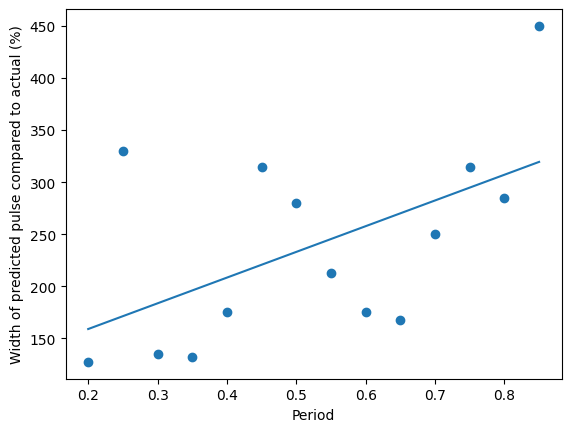

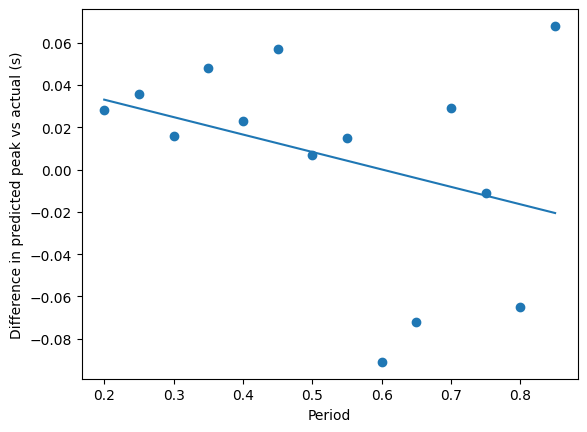

In [4]:
#from sklearn.metrics import r2_score

a,b = np.polyfit(range_array, half_max_width, 1)

plt.figure()
plt.scatter(range_array, half_max_width)
plt.plot(range_array, a*range_array+b)
plt.ylabel("Width of predicted pulse compared to actual (%)")
plt.xlabel("Period")
plt.savefig('noise_half_max_width.png', transparent=True)

a,b = np.polyfit(range_array, position_error, 1)

plt.figure()
plt.ylabel("Difference in predicted peak vs actual (s)")
plt.xlabel("Period")
plt.scatter(range_array, position_error)
plt.plot(range_array, a*range_array+b)

plt.savefig('noise_timing_error.png', transparent=True)

plt.show()

import pickle

filename = "noise std - 0.01 data"
pickle.dump([(half_max_width, range_array), (position_error, range_array)], open(filename, 'wb'))



In [1]:

import pickle
import FF_Demo
import numpy as np

#loads saved model from the same directory
rnn = pickle.load(open("model22-noise_std-0.001-2000-full-period-20-20-0.5",'rb'))

#defines arrays to store errors for each period
half_max_width = [] 
position_error = []

#defines range for testing periods
range_array = np.arange(0.2,0.9,0.05)

#loop to test multiple periods
for item in range_array:
    #calls test function from FF_demo.py on different periods
    x = rnn.test(specific_pulse, period = item)
    plt.figure()

    #stores the target output and model output
    fin = x[0][0];ftarg = x[0][1]; fout = x[0][2]

    #finds each pulse in the target output and stores the indicies in groups of 5
    a = np.where(ftarg >= 0.7)
    a = np.array_split(a[0],5)

    #finds the location of the predicted pulse and inserts it
    idx = a[4][0] + abs(a[4][0] -  a[3][0])
    ftarg = np.concatenate((ftarg[:idx], np.full_like(np.zeros((40, 1)),0.9), ftarg[idx:]), axis=0)
    
    #plots the output with the predicted pulse
    plt.plot(fin)
    plt.plot(fout)
    plt.plot(ftarg)
    
    #defines positions: check range = how far left and right values are checked
    check_range = 100 
    check_left = idx - check_range
    check_right = idx + check_range
    check_slice = fout[check_left:check_right]
    
    #find the maximal value of model output
    max_val = np.max(check_slice)
    
    #finds index of maximal value of model output relative to slice
    max_out_near_predict = np.argmax(check_slice)
    
    #absolute index in fout of maxical value
    model_max_index = max_out_near_predict + check_left
    
    #target index of predict pulse
    predict = idx + 20
    
    #plots target prediction point and model prediction point
    plt.scatter(predict, 0.75,4)
    plt.scatter(model_max_index,0.75,4)
    
    #calculates the time error in seconds
    time_from_target = 0.001*((check_left+max_out_near_predict)-(predict))

    #reports time error
    if time_from_target < 0: 
        print(f"The predicted pulse peak is {abs(time_from_target)} seconds early")
    else:
        print(f"The predicted pulse peak is {time_from_target} seconds late")
        
    #stores time error
    position_error.append(time_from_target)
    
    #check index centred on model predict
    check_model_left = model_max_index - check_range
    
    half_max = 0.25+max_val/2
    
    #calculates the index for 1/2 max out put for left side and right side of the pulse
    pulse_left = check_model_left + np.abs(fout[check_model_left:model_max_index] - half_max).argmin()
    pulse_right = model_max_index + np.abs(fout[model_max_index:model_max_index+100] - half_max).argmin()

    #plots the 1/2 max on the left and right size
    plt.scatter([pulse_left,pulse_right], [half_max,half_max],4)
    #plt.scatter(pulse_right, 0.25+max_val/2,4)

    #calculates size of model predict relative to target predict
    pulse_size_error =  100*abs(pulse_left-pulse_right)/40

    print(f"The width of the predicted pulse at half-max is {pulse_size_error}% the size of input")
    
    #stores size of model predict
    half_max_width.append(pulse_size_error)
    plt.figure()



plt.figure()
plt.scatter(range_array, half_max_width)
plt.figure()
plt.scatter(range_array, position_error)
plt.show()
#print(error_to_plot)


NameError: name 'specific_pulse' is not defined

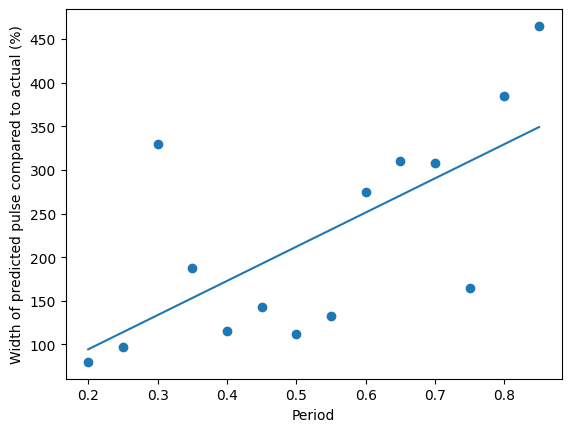

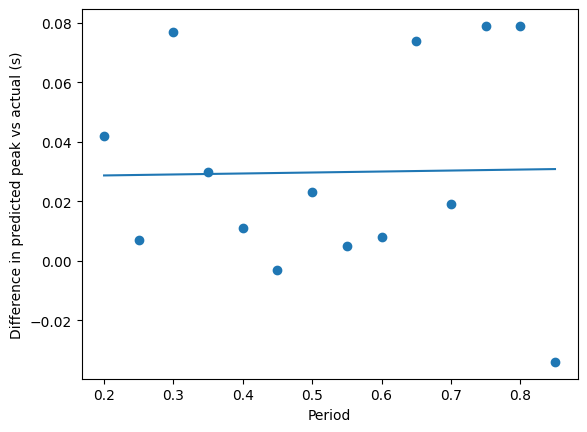

In [41]:
#from sklearn.metrics import r2_score

a,b = np.polyfit(range_array, half_max_width, 1)

plt.figure()
plt.scatter(range_array, half_max_width)
plt.plot(range_array, a*range_array+b)
plt.ylabel("Width of predicted pulse compared to actual (%)")
plt.xlabel("Period")

a,b = np.polyfit(range_array, position_error, 1)

plt.figure()
plt.ylabel("Difference in predicted peak vs actual (s)")
plt.xlabel("Period")
plt.scatter(range_array, position_error)
plt.plot(range_array, a*range_array+b)
plt.show()
